In [1]:
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import common

SEED = 42


def set_seed(seed: int = 42) -> None:
    """난수 시드를 고정한다."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"

print(f"using PyTorch version: {torch.__version__}, Device: {DEVICE}")

using PyTorch version: 2.6.0+cu124, Device: cuda


In [2]:
# MinMax 노트북과 같은 3분봉 CSV를 쓴다. 원본 GRU_RevIN5는 5분봉이라 비교가 불가능했다.
data = common.load_data(path="data/BTC_3min_2024-10.csv")

print(f"data shape: {data.shape}")
data.head()

data shape: (13436, 9)


,open,high,low,close,volume,value,ma_3,ma_5,middle
2024-10-03 12:39:00,82505000.0,82505000.0,82427000.0,82505000.0,2.966659,2.447083e+08,8.253700e+07,82558400.0,82466000.0
2024-10-03 12:42:00,82500000.0,82505000.0,82423000.0,82499000.0,1.690431,1.393662e+08,8.249833e+07,82546000.0,82464000.0
2024-10-03 12:45:00,82499000.0,82593000.0,82433000.0,82482000.0,3.699225,3.052489e+08,8.249533e+07,82518400.0,82513000.0
2024-10-03 12:48:00,82590000.0,82591000.0,82500000.0,82589000.0,0.558138,4.609081e+07,8.252333e+07,82513200.0,82545500.0
2024-10-03 12:51:00,82590000.0,82610000.0,82540000.0,82609000.0,2.760618,2.280237e+08,8.256000e+07,82536800.0,82575000.0


In [3]:
MODEL_NAME = "LSTM RevIN"

FEATURE_NUMS = 8
SEQ_LENGTH = 288
HIDDEN_SIZE = 4
NUM_LAYERS = 1
LEARNING_RATE = 1e-3
BATCH_SIZE = 20
NUM_WORKERS = 0

TRAIN_RATIO = 0.7
FIT_TRAIN_RATIO = 0.8
REVIN_TARGET_EPS = 1e-5

MAX_EPOCHS = 200
PATIENCE = 15

In [4]:
# RevIN은 인스턴스 정규화라 sklearn 스케일러를 쓰지 않는다.
# 입력은 원 단위로 두고 모델 안 RevIN이 윈도마다 채널별로 정규화한다.
train_df, test_df = common.split_data(data, train_ratio=TRAIN_RATIO)
train_fit_df, val_df = common.split_data(train_df, train_ratio=FIT_TRAIN_RATIO)


def revin_parts(frame):
    return common.make_revin_sequences(
        frame,
        seq_length=SEQ_LENGTH,
        n_features=FEATURE_NUMS,
        target_col="middle",
        eps=REVIN_TARGET_EPS,
    )


x_train_raw, y_train_raw, train_win_mean, train_win_std = revin_parts(train_fit_df)
x_val_raw, y_val_raw, val_win_mean, val_win_std = revin_parts(val_df)
x_test_raw, y_test_raw, test_win_mean, test_win_std = revin_parts(test_df)

# 타깃은 그 윈도의 middle 평균/표준편차로 정규화한다. 통계는 입력 구간에서만 계산된다.
y_train_norm = (y_train_raw - train_win_mean) / train_win_std
y_val_norm = (y_val_raw - val_win_mean) / val_win_std
y_test_norm = (y_test_raw - test_win_mean) / test_win_std

# test_df는 split_data가 돌려준 원 단위 DataFrame이다.
naive_test_raw = common.naive_baseline_from_df(test_df, SEQ_LENGTH)

expected_train_samples = len(train_fit_df) - SEQ_LENGTH
expected_val_samples = len(val_df) - SEQ_LENGTH
expected_test_samples = len(test_df) - SEQ_LENGTH

if min(expected_train_samples, expected_val_samples, expected_test_samples) <= 0:
    raise ValueError("SEQ_LENGTH보다 각 구간의 행 수가 충분히 커야 합니다.")

if x_train_raw.shape[0] != expected_train_samples or y_train_norm.shape[0] != expected_train_samples:
    raise ValueError("학습 시퀀스 표본 수가 train_fit_df와 맞지 않습니다.")

if x_val_raw.shape[0] != expected_val_samples or y_val_norm.shape[0] != expected_val_samples:
    raise ValueError("검증 시퀀스 표본 수가 val_df와 맞지 않습니다.")

if x_test_raw.shape[0] != expected_test_samples or y_test_norm.shape[0] != expected_test_samples:
    raise ValueError("테스트 시퀀스 표본 수가 test_df와 맞지 않습니다.")

if naive_test_raw.shape != y_test_raw.shape:
    raise ValueError("원 단위 naive 기준선과 최종 테스트 타깃의 표본 수가 맞지 않습니다.")

print(f"train samples: {x_train_raw.shape[0]}")
print(f"val samples: {x_val_raw.shape[0]}")
print(f"test samples: {x_test_raw.shape[0]}")

train samples: 7236
val samples: 1593
test samples: 3743


In [5]:
train_dataset = TensorDataset(
    torch.from_numpy(x_train_raw).float(),
    torch.from_numpy(y_train_norm).float(),
    torch.from_numpy(train_win_mean).float(),
    torch.from_numpy(train_win_std).float(),
)
val_dataset = TensorDataset(
    torch.from_numpy(x_val_raw).float(),
    torch.from_numpy(y_val_norm).float(),
    torch.from_numpy(val_win_mean).float(),
    torch.from_numpy(val_win_std).float(),
)
test_dataset = TensorDataset(
    torch.from_numpy(x_test_raw).float(),
    torch.from_numpy(y_test_norm).float(),
    torch.from_numpy(test_win_mean).float(),
    torch.from_numpy(test_win_std).float(),
)

# 시계열이므로 학습 배치도 셔플하지 않는다.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

In [6]:
class RevIN(nn.Module):
    """ts-kim/RevIN 원본 구현.

    핵심은 (batch, seq, channel) 3차원 입력에 걸어야 dim2reduce가 (1,)이 되어
    윈도마다 채널별로 정규화된다는 점이다. 2차원 텐서에 걸면 전체가 스칼라 하나로
    정규화되어 RevIN이 아니게 된다.
    """

    def __init__(self, num_features: int, eps=1e-5, affine=True):
        super(RevIN, self).__init__()
        self.num_features = num_features
        self.eps = eps
        self.affine = affine

        if self.affine:
            self._init_params()

    def forward(self, x, mode: str):
        if mode == "norm":
            self._get_statistics(x)
            x = self._normalize(x)
        elif mode == "denorm":
            x = self._denormalize(x)
        else:
            raise NotImplementedError

        return x

    def _init_params(self):
        self.affine_weight = nn.Parameter(torch.ones(self.num_features))
        self.affine_bias = nn.Parameter(torch.zeros(self.num_features))

    def _get_statistics(self, x):
        dim2reduce = tuple(range(1, x.ndim - 1))
        self.mean = torch.mean(x, dim=dim2reduce, keepdim=True).detach()
        self.stdev = torch.sqrt(
            torch.var(x, dim=dim2reduce, keepdim=True, unbiased=False) + self.eps
        ).detach()

    def _normalize(self, x):
        x = x - self.mean
        x = x / self.stdev

        if self.affine:
            x = x * self.affine_weight
            x = x + self.affine_bias

        return x

    def _denormalize(self, x):
        if self.affine:
            x = x - self.affine_bias
            x = x / (self.affine_weight + self.eps * self.eps)

        x = x * self.stdev
        x = x + self.mean
        return x

In [7]:
class MyLSTMRevIN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size

        self.revin = RevIN(num_features=input_size, affine=True)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq, 8) 원 단위. 여기서 dim2reduce가 (1,)이 되어 채널별 정규화가 맞게 돈다.
        x = self.revin(x, "norm")

        h0 = x.new_zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = x.new_zeros(self.num_layers, x.size(0), self.hidden_size)

        out, _ = self.lstm(x, (h0, c0))
        return self.fc(out[:, -1, :])

In [8]:
def init_weights(module):
    if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        if module.bias is not None:
            nn.init.constant_(module.bias, 0.01)


set_seed(SEED)

model = MyLSTMRevIN(FEATURE_NUMS, HIDDEN_SIZE, NUM_LAYERS).to(DEVICE)
model.apply(init_weights)

loss_function = nn.MSELoss()

# RevIN이 모델 안에 있으므로 model.parameters()에 affine 파라미터가 자동 포함된다.
# 원본은 revin을 모델 밖에 두어 affine이 전혀 학습되지 않았다.
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

revin_params = sum(p.numel() for n, p in model.named_parameters() if "revin" in n)
print(f"{MODEL_NAME}: revin 학습 파라미터 {revin_params}개 (0이면 잘못된 것)")

LSTM RevIN: revin 학습 파라미터 16개 (0이면 잘못된 것)


In [9]:
def run_epoch(dataloader, model, loss_function, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    loss_sum = 0.0
    sample_count = 0

    with torch.set_grad_enabled(is_train):
        for inputs, y_norm, _, _ in dataloader:
            inputs = inputs.to(DEVICE, non_blocking=PIN_MEMORY)
            y_norm = y_norm.to(DEVICE, non_blocking=PIN_MEMORY)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            pred_norm = model(inputs)
            loss = loss_function(pred_norm, y_norm)

            if is_train:
                loss.backward()
                optimizer.step()

            batch_size = inputs.size(0)
            loss_sum += loss.item() * batch_size
            sample_count += batch_size

    if sample_count == 0:
        raise ValueError("DataLoader에 평가할 표본이 없습니다.")

    return loss_sum / sample_count


def predict(dataloader, model):
    """정규화 공간의 예측을 윈도 통계로 원 단위까지 되돌려 반환한다."""
    model.eval()
    predictions = []

    with torch.no_grad():
        for inputs, _, win_mean, win_std in dataloader:
            inputs = inputs.to(DEVICE, non_blocking=PIN_MEMORY)
            win_mean = win_mean.to(DEVICE, non_blocking=PIN_MEMORY)
            win_std = win_std.to(DEVICE, non_blocking=PIN_MEMORY)

            pred_norm = model(inputs)
            pred_raw = pred_norm * win_std + win_mean

            predictions.append(pred_raw.detach().cpu().numpy())

    if not predictions:
        raise ValueError("테스트 예측 표본이 없습니다.")

    return np.concatenate(predictions, axis=0)

In [10]:
train_loss_list = []
val_loss_list = []

best_val_loss = float("inf")
best_state = None
best_epoch = 0
stale_epochs = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = run_epoch(train_loader, model, loss_function, optimizer)
    val_loss = run_epoch(val_loader, model, loss_function)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch
        stale_epochs = 0
    else:
        stale_epochs += 1

    if epoch == 1 or epoch % 10 == 0:
        print(f"Epoch [{epoch}/{MAX_EPOCHS}] train_loss={train_loss:.8f}, val_loss={val_loss:.8f}")

    if stale_epochs >= PATIENCE:
        print(f"early stopping: epoch={epoch}, patience={PATIENCE}")
        break

if best_state is None:
    raise RuntimeError("최고 검증 손실 가중치를 저장하지 못했습니다.")

model.load_state_dict(best_state)

print(f"{MODEL_NAME} best epoch: {best_epoch}, best val loss: {best_val_loss:.8f}")

Epoch [1/200] train_loss=0.75912851, val_loss=0.34769946


Epoch [10/200] train_loss=0.04897491, val_loss=0.03368069


Epoch [20/200] train_loss=0.03334712, val_loss=0.02693253


Epoch [30/200] train_loss=0.02940958, val_loss=0.02519435


Epoch [40/200] train_loss=0.02770742, val_loss=0.02444859


...

Epoch [130/200] train_loss=0.02428451, val_loss=0.02362369


Epoch [140/200] train_loss=0.02416421, val_loss=0.02360668


Epoch [150/200] train_loss=0.02405427, val_loss=0.02360434


Epoch [160/200] train_loss=0.02395316, val_loss=0.02361373


early stopping: epoch=162, patience=15
LSTM RevIN best epoch: 147, best val loss: 0.02360362


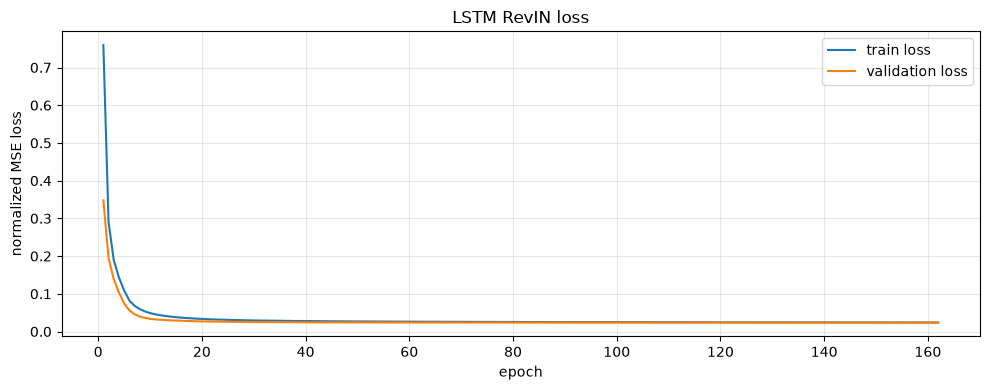

In [11]:
epochs = np.arange(1, len(train_loss_list) + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs, train_loss_list, label="train loss")
plt.plot(epochs, val_loss_list, label="validation loss")
plt.xlabel("epoch")
plt.ylabel("normalized MSE loss")
plt.title(f"{MODEL_NAME} loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
pred_raw = predict(test_loader, model)

if pred_raw.shape != y_test_raw.shape:
    raise ValueError("원 단위 모델 예측과 테스트 타깃의 표본 수가 맞지 않습니다.")

if pred_raw.shape != naive_test_raw.shape:
    raise ValueError("원 단위 모델 예측과 naive 기준선의 표본 수가 맞지 않습니다.")

# 이미 원 단위이므로 inverse_fn은 쓰지 않는다. MinMax 노트북과 같은 표본, 같은 단위다.
result = common.compare_to_naive(
    model_pred=pred_raw,
    naive_pred=naive_test_raw,
    true=y_test_raw,
    name=MODEL_NAME,
    unit="원",
)
common.save_result(result)

print(f"naive 대비 MAE 배수: {result['mae_ratio']:.3f}  (1보다 크면 naive보다 나쁨)")
common.report_table([result])

naive 대비 MAE 배수: 0.845  (1보다 크면 naive보다 나쁨)


,모델,MAE,RMSE,MAPE(%),naive대비MAE배수,모델이naive를이김
0,LSTM RevIN,32614.8843,46145.6989,0.0339,0.845,True


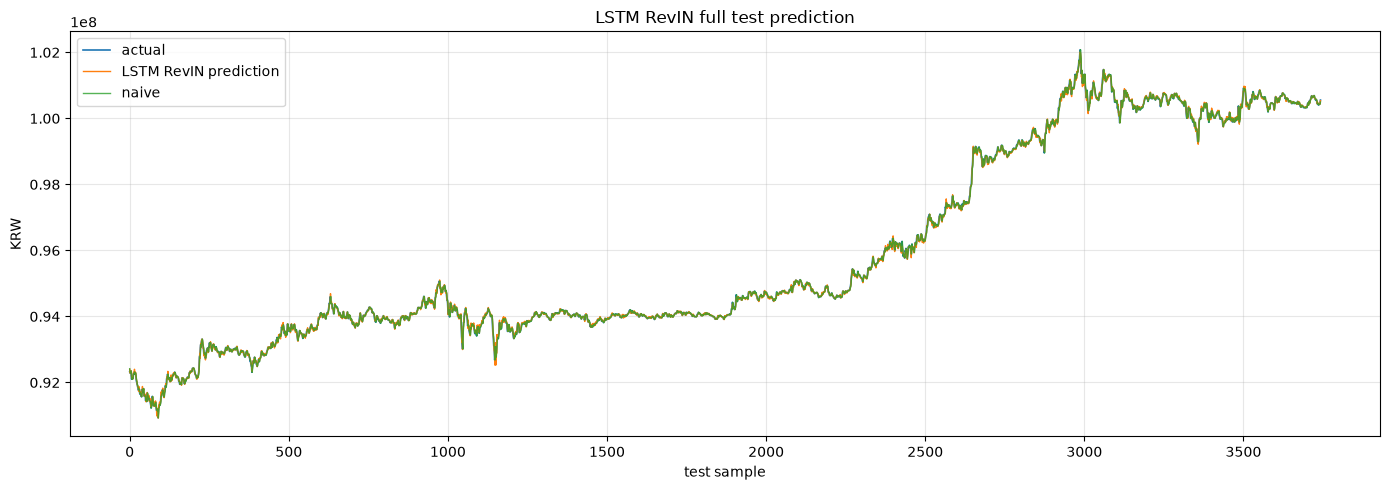

In [13]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_raw.reshape(-1), label="actual", linewidth=1.2)
plt.plot(pred_raw.reshape(-1), label=f"{MODEL_NAME} prediction", linewidth=1.0)
plt.plot(naive_test_raw.reshape(-1), label="naive", linewidth=1.0, alpha=0.8)
plt.xlabel("test sample")
plt.ylabel("KRW")
plt.title(f"{MODEL_NAME} full test prediction")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

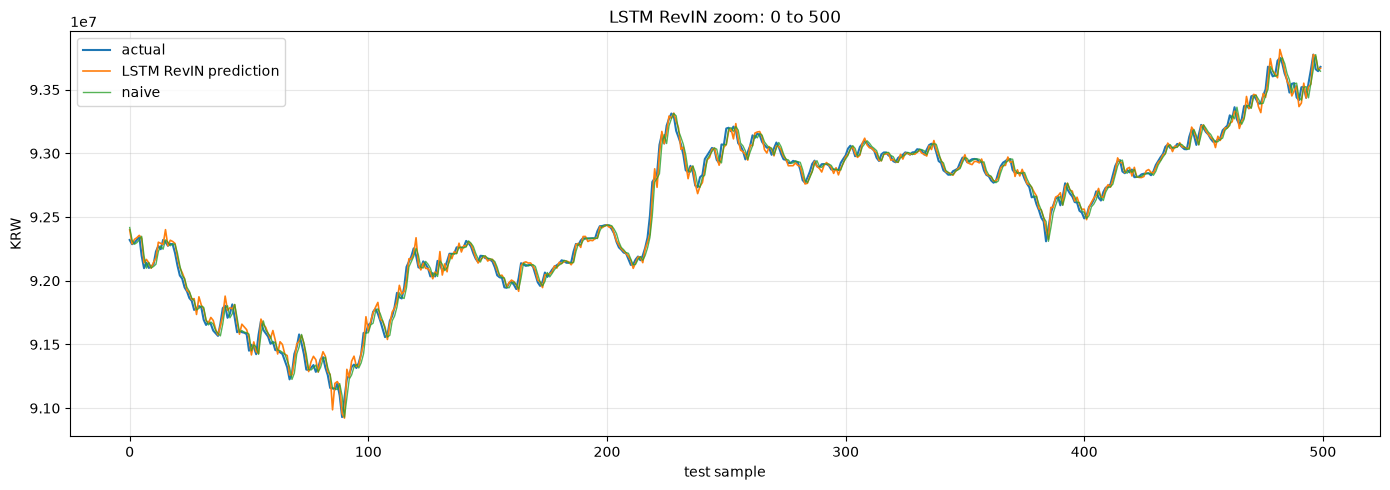

In [14]:
start_idx = 0
end_idx = min(500, len(y_test_raw))

plt.figure(figsize=(14, 5))
plt.plot(y_test_raw[start_idx:end_idx].reshape(-1), label="actual", linewidth=1.5)
plt.plot(pred_raw[start_idx:end_idx].reshape(-1), label=f"{MODEL_NAME} prediction", linewidth=1.2)
plt.plot(naive_test_raw[start_idx:end_idx].reshape(-1), label="naive", linewidth=1.0, alpha=0.8)
plt.xlabel("test sample")
plt.ylabel("KRW")
plt.title(f"{MODEL_NAME} zoom: {start_idx} to {end_idx}")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()